# **Trabajo Práctico N°1: modelo predictivo de tarifas de Uber**


# Contexto del problema

El proyecto se centra en el análisis de datos de viajes realizados por Uber. El objetivo principal es predecir la tarifa de futuros viajes (`fare_amount`) a partir de distintas características disponibles en el dataset. El dataset utilizado contiene información sobre viajes realizados en Uber junto con el costo de cada uno. Cada fila representa un viaje individual e incluye distintas variables descriptivas que permiten caracterizarlo.

Variables de entrada:

- **key**: identificador único del viaje.
- **pickup_datetime**: fecha y hora en que comienza el viaje.
- **passenger_count**: cantidad de pasajeros en el vehículo.
- **pickup_longitude / pickup_latitude**: coordenadas geográficas donde inicia el viaje.
- **dropoff_longitude / dropoff_latitude**: coordenadas geográficas donde finaliza el viaje.

Variable objetivo

- **fare_amount**: costo total del viaje en dólares (USD), variable que se desea predecir.


# Importación de librerias y dataset

In [11]:
import pandas as pd
import numpy as np
import holidays
import seaborn as sns
import matplotlib.pyplot as plt
import time as time


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import RobustScaler,  StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression, SGDRegressor, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error

In [12]:
df= pd.read_csv("uber_fares.csv")

# Análisis descriptivo

Detectamos inconsistencias en algunas variables. En particular, las coordenadas geográficas (pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude) presentan valores fuera de rango (por ejemplo, longitudes y latitudes extremadamente grandes), lo cual indica la presencia de datos erróneos. A su vez, la variable passenger_count contiene valores atípicos, como 0 pasajeros o valores excesivamente altos, que no tienen sentido en el contexto del problema. Por otro lado, se observa la presencia de una cantidad mínima de valores faltantes en variables como dropoff_longitude, dropoff_latitude y passenger_count, por lo que se optará por eliminarlos. Finalmente, la variable objetivo fare_amount presenta una distribución sesgada hacia valores altos.


In [13]:
n_inicial = len(df)
print(n_inicial)

200000


In [14]:
print(df.columns)
df.info()
df.describe()

Index(['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.362915,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.943248,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,1.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,5.970000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.430000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.660000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,503.130000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [15]:
df.isnull().sum()

,0
key,0
date,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,1
dropoff_latitude,1
passenger_count,0


In [16]:
df[df.isnull().any(axis=1)]

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,2013-07-02 03:53:05,24.15,2013-07-02 03:53:05 UTC,-73.950581,40.779692,NaN,NaN,0


# Limpieza de datos


### Análisis de las coordenadas


Se detectaron registros con valores iguales a cero en las coordenadas geográficas, tanto en el origen como en el destino. Si bien el punto (0,0) existe geográficamente, no corresponde al área de estudio (Nueva York) y suele indicar errores de registro o datos faltantes, mas adelante se hara una imputación.

In [17]:
cond_any_00 = ((df['pickup_latitude'] == 0) | (df['pickup_longitude'] == 0) | (df['dropoff_latitude'] == 0) | (df['dropoff_longitude'] == 0))
print("Total con coordenadas inválidas:", cond_any_00.sum())
#luego las imputamos con KNN

Total con coordenadas inválidas: 3968


In [18]:
(df[['pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude']] == 0).sum()

,0
pickup_latitude,3782
pickup_longitude,3786
dropoff_latitude,3758
dropoff_longitude,3764


In [19]:
#borramos la fila que no tiene latitud ni longitud de destino, tambien observamos que el nro de pasajeros es 0 por lo cual tambien nos ayudo a tomar la decision ya que no podia existir un viaje que no tenga pasajeros
df = df.dropna(subset=['dropoff_latitude', 'dropoff_longitude'])

In [20]:
n_final = len(df)
eliminadas = n_inicial - n_final
porcentaje = (eliminadas / n_inicial) * 100
print(f"Cantidad de filas eliminadas: {eliminadas}")
print(f"Porcentaje de filas eliminadas: {porcentaje:.2f}%")

Cantidad de filas eliminadas: 1
Porcentaje de filas eliminadas: 0.00%


Consideramos eliminar la fila que no tenia valores en las columnas dropoff_longitude y dropoff_latitude ya que si falta la latitud del destino no podemos saber dónde terminó el viaje y tampoco podemos calcular la distancia, a su vez este registro que no presentaba datos en dichas columnas, tampoco presentaba pasajeros, lo cual nos permitio tomar la decision aun mas seguros, ya que no puede existir un viaje sin pasajero.

In [21]:
condicion = ((df['pickup_latitude'] > 90) | (df['pickup_latitude'] < -90) |
    (df['pickup_longitude'] > 180) | (df['pickup_longitude'] < -180) |
    (df['dropoff_latitude'] > 90) | (df['dropoff_latitude'] < -90) |
    (df['dropoff_longitude'] > 180) | (df['dropoff_longitude'] < -180)) #marcamos como True todas las filas donde al menos una coordenada esté fuera de rango

df.loc[condicion, ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']]

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
4949,40.739957,-748.016667,40.734192,-74.003570
32549,40.715155,-74.016055,40.697862,-737.916665
48506,40.770092,-735.200000,40.765530,-73.980187
56617,404.433332,-73.960828,40.769037,-73.988357
61793,401.066667,-73.951385,40.754117,-73.982110
75851,1644.421482,-1340.648410,872.697628,-3356.666300
91422,1292.016128,57.418457,-881.985513,1153.572603
103745,40.767035,-736.216667,40.725562,-73.982377
139447,40.709780,-74.011042,493.533332,-73.983163
144253,40.757812,-768.550000,40.740007,-73.997040


In [22]:
cond_extra = df['pickup_latitude'] > 1000
df.loc[cond_extra] #mostramos las filas que siguen siendo inconsistentes a pesar del filtro

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
75851,33249845,2011-11-05 00:20:52,16.74,2011-11-05 00:20:52 UTC,-1340.648410,1644.421482,-3356.666300,872.697628,1
91422,23566642,2011-05-18 13:22:56,16.14,2011-05-18 13:22:56 UTC,57.418457,1292.016128,1153.572603,-881.985513,1


In [23]:
#eliminamos las filas que seguian siendo inconsistentes a pesar de la condicion
df = df.drop(df[(df['pickup_latitude'] > 1000)].index)

In [24]:
n_final = len(df)
eliminadas = n_inicial - n_final
porcentaje = (eliminadas / n_inicial) * 100
print(f"Cantidad de filas eliminadas: {eliminadas}")
print(f"Porcentaje de filas eliminadas: {porcentaje:.2f}%")

Cantidad de filas eliminadas: 3
Porcentaje de filas eliminadas: 0.00%


Detectamos valores atípicos en las coordenadas geográficas que excedían los rangos válidos (latitud entre -90 y 90, longitud entre -180 y 180). Al analizar estos casos, pensamos que podrian ser errores de tipeo en la coma decimal (por ejemplo, valores del orden de 400 en lugar de 40). En lugar de eliminar estas observaciones, se optó por corregirlas dividiendo los valores por 10, ya que de esta manera se recupera información válida sin introducir ruido significativo en el modelo.

In [25]:
pickup_lat = (df['pickup_latitude'] > 90) | (df['pickup_latitude'] < -90)
pickup_lon = (df['pickup_longitude'] > 180) | (df['pickup_longitude'] < -180)
drop_lat   = (df['dropoff_latitude'] > 90) | (df['dropoff_latitude'] < -90)
drop_lon   = (df['dropoff_longitude'] > 180) | (df['dropoff_longitude'] < -180)

df.loc[pickup_lat, 'pickup_latitude'] /= 10
df.loc[pickup_lon, 'pickup_longitude'] /= 10
df.loc[drop_lat, 'dropoff_latitude']  /= 10
df.loc[drop_lon, 'dropoff_longitude'] /= 10

condicion = ((df['pickup_latitude'] > 90) | (df['pickup_latitude'] < -90) |
    (df['pickup_longitude'] > 180) | (df['pickup_longitude'] < -180) |
    (df['dropoff_latitude'] > 90) | (df['dropoff_latitude'] < -90) |
    (df['dropoff_longitude'] > 180) | (df['dropoff_longitude'] < -180))

df.loc[condicion, ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']]

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude


### Análisis de la variable passenger_count

In [26]:
df['passenger_count'].describe() #podemos observar valores incoherentes, como la maxima y la minima

,passenger_count
count,199997.00000
mean,1.68455
std,1.38600
min,0.00000
25%,1.00000
50%,1.00000
75%,2.00000
max,208.00000


Se detectaron valores atípicos como 0 pasajeros y valores excesivamente altos, los cuales no son coherentes con la capacidad de un vehículo típico. Por este motivo, se decidió conservar únicamente los valores entre 1 y 6 pasajeros, eliminando aquellos registros que no representan situaciones reales.


In [27]:
#eliminamos los menores a 1 y los mayores que 6
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] < 7)]

In [28]:
n_final = len(df)
eliminadas = n_inicial - n_final
porcentaje = (eliminadas / n_inicial) * 100
print(f"Cantidad de filas eliminadas: {eliminadas}")
print(f"Porcentaje de filas eliminadas: {porcentaje:.2f}%")

Cantidad de filas eliminadas: 712
Porcentaje de filas eliminadas: 0.36%


In [29]:
df['passenger_count'].describe()  #chequeamos

,passenger_count
count,199288.000000
mean,1.689500
std,1.305424
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,6.000000


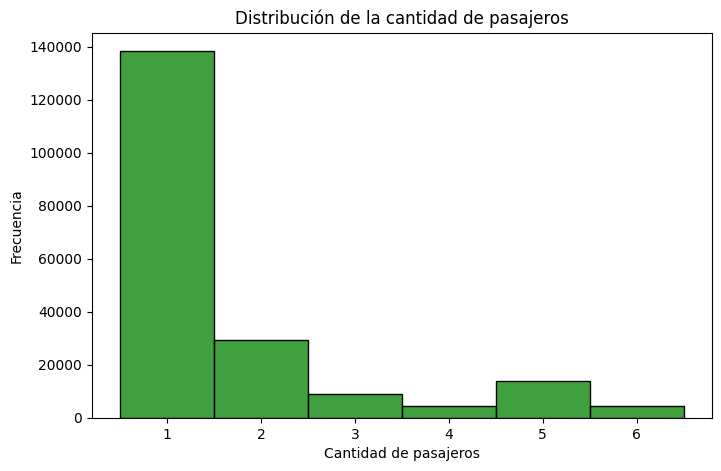

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df['passenger_count'], bins=10, discrete=True, color="green")
plt.title("Distribución de la cantidad de pasajeros")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Frecuencia")
plt.show()

### Análisis de la variable fare_amount


In [31]:
df['fare_amount'].describe()

,fare_amount
count,199288.000000
mean,11.369517
std,9.952179
min,1.000000
25%,5.970000
50%,8.430000
75%,12.670000
max,503.130000


In [32]:
df = df[df['fare_amount'] > 0] #eliminamos tarifas que son menores a 0

In [33]:
df.loc[df['fare_amount'] == 503.13] #cuando calculamos la distancia de este registro podemos ver que no hay logica entre el precio y la distancia recorrida

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
170081,51151143,2011-04-10 04:10:01,503.13,2011-04-10 04:10:01 UTC,-73.968377,40.764602,-73.968368,40.7646,1


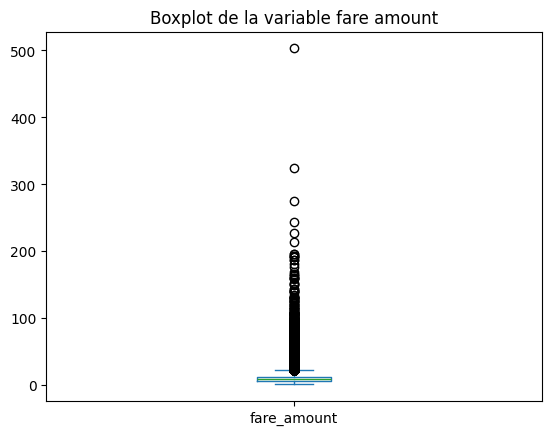

In [34]:
df['fare_amount'].head()

df['fare_amount'].plot(kind='box')
plt.title("Boxplot de la variable fare amount")
plt.show()


 En el **Boxplot** podemos observar que la caja está casi pegada al cero, lo que confirma que la gran mayoría de los viajes son cortos y baratos. Respecto a los valores atipicos podemos observar que hay costos de viajes muy altos (500). Estos valores ensucian el promedio, haciendo que parezca que los viajes son más caros de lo que realmente son.

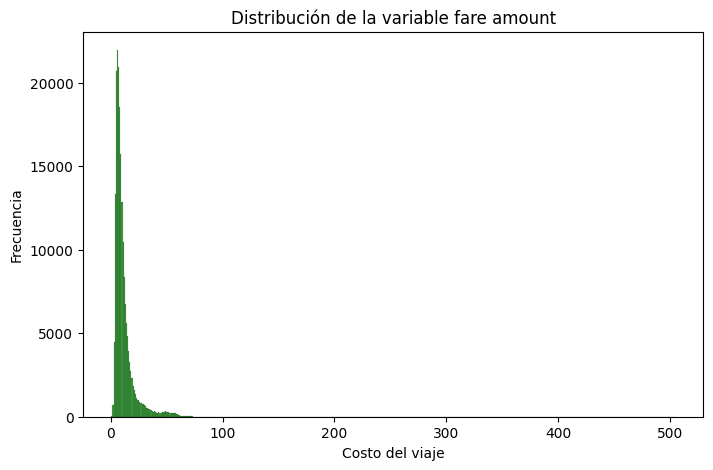

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df['fare_amount'], bins=10, discrete=True, color="green")
plt.title("Distribución de la variable fare amount")
plt.xlabel("Costo del viaje")
plt.ylabel("Frecuencia")
plt.show()

El **Histograma de Distribución** presenta un sesgo a la derecha, lo que nos indica que la moda es una tarifa baja, probablemente entre 8 y 12 dólares. La cola larga, confirma lo que vimos en el boxplot, que hay muy pocos viajes caros.

In [36]:
#calculamos limites
limite_tarifa = df["fare_amount"].quantile(0.999)
df = df[df['fare_amount'] <= limite_tarifa]

Se utilizó el cuantil 0.999 para eliminar valores atípicos extremos en la tarifa, asegurando que el modelo no se vea sesgado por registros excepcionales que no representan el comportamiento habitual del servicio

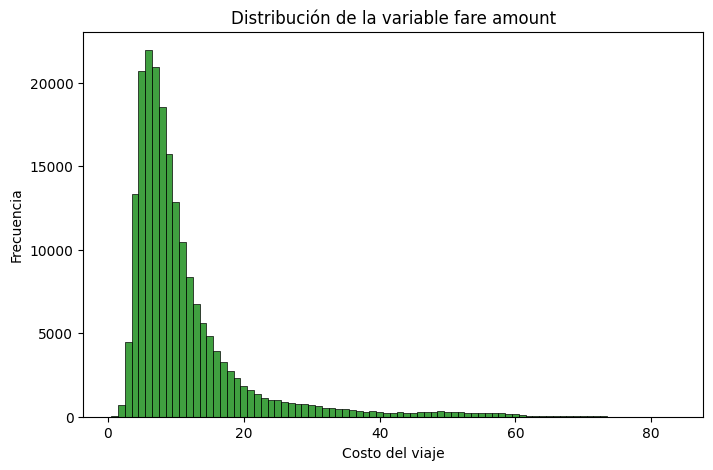

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df['fare_amount'], bins=10, discrete=True, color="green")
plt.title("Distribución de la variable fare amount")
plt.xlabel("Costo del viaje")
plt.ylabel("Frecuencia")
plt.show()

In [38]:
n_final = len(df)
eliminadas = n_inicial - n_final
porcentaje = (eliminadas / n_inicial) * 100
print(f"Cantidad de filas eliminadas: {eliminadas}")
print(f"Porcentaje de filas eliminadas: {porcentaje:.2f}%")

Cantidad de filas eliminadas: 912
Porcentaje de filas eliminadas: 0.46%


# Creacion de variables nuevas


Decidimos agregar las variables de tiempo ya que al separar la fecha en componentes individuales permite al modelo lineal captar tendencias, variaciones de demanda diaria y de las distintas horas del dia. A su vez agregamos variables para poder diferenciar los Feriados y Fines de Semana y los dias laborales ya que los patrones de tráfico y demanda podrian cambian en días dependiendo el día.

In [39]:
pickup_dt = pd.to_datetime(df['pickup_datetime'])

df['hour'] = pickup_dt.dt.hour
df['day_of_week'] = pickup_dt.dt.dayofweek #dia de la semana
df['day'] = pickup_dt.dt.day #dia del mes
df['month'] = pickup_dt.dt.month
df['year'] = pickup_dt.dt.year

#solo fecha, sin hora
df['date'] = pickup_dt.dt.date

#feriados
us_holidays = holidays.US(years=df['year'].unique(), state='NY')

df['is_weekend'] = df['day_of_week'].isin([5, 6])
df['is_holiday'] = df['date'].isin(us_holidays)

In [40]:
meses_presentes = df[df['year'] == 2015]['month'].nunique()
print(f"Meses con datos en el año 2015: {meses_presentes}")

Meses con datos en el año 2015: 6


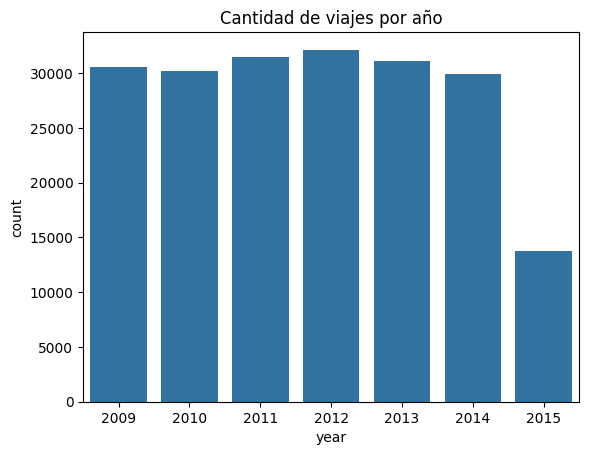

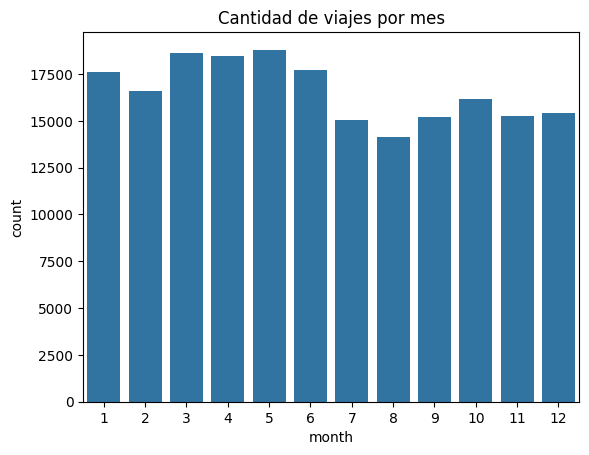

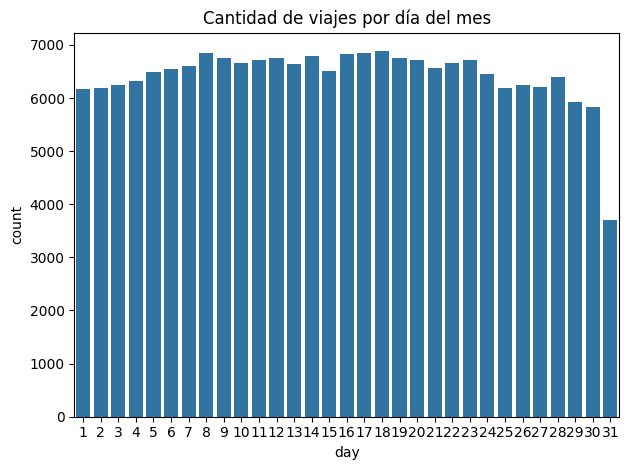

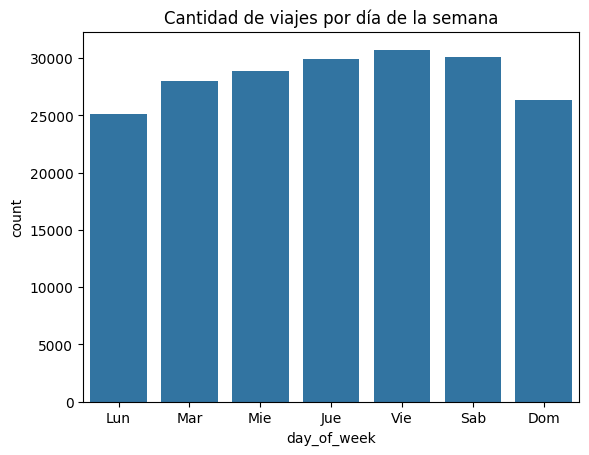

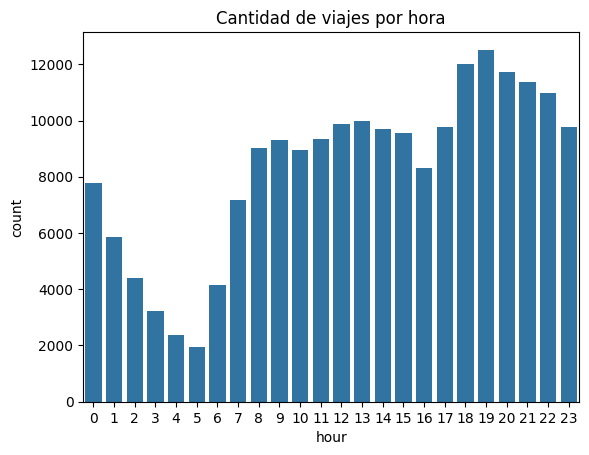

In [41]:
sns.countplot(df, x='year')
plt.title("Cantidad de viajes por año")
plt.show()

sns.countplot(df, x='month')
plt.title("Cantidad de viajes por mes")
plt.show()


sns.countplot(df, x='day')
plt.title("Cantidad de viajes por día del mes")
plt.tight_layout()
plt.show()

dias = ['Lun','Mar','Mie','Jue','Vie','Sab','Dom']
sns.countplot(df, x='day_of_week')
plt.xticks(ticks=range(7), labels=dias)
plt.title("Cantidad de viajes por día de la semana")
plt.show()


sns.countplot(df, x='hour')
plt.title("Cantidad de viajes por hora")
plt.show()



- En el grafico que muestra la **cantidad de viajes por año** se ve una estabilidad clara entre 2009 y 2014, con un volumen cercano a los 30,000 viajes anuales. Sin embargo, en 2015 la barra cae drásticamente (menos de 15,000), esto indica que el dataset de 2015 está incompleto (solo llega hasta la mitad del año).
- Luego la en **cantidad de viajes por mes** hay un pico de actividad entre marzo y junio, con un descenso notable en julio y agosto.

- En la **cantidad de viajes por día del mes** se ve una distribución muy uniforme y estable. La mayoría de los días se mantienen entre los 6,000 y 7,000 viajes. Hay un leve descenso a partir del día 28. Esto indica que la demanda de transporte es constante a lo largo de todo el mes; la gente no viaja más al principio que al final. La caída al final (días 29, 30 y 31) no es falta de interés, sino que todos los meses tienen 28 días, pero no todos tienen 30 o 31, por lo que hay menos datos acumulados en esos valores finales.

- La **Cantidad de viajes por día de la semana** podemos observar que el domingo es el día con menos actividad después del lunes. Los Viernes y Sábados son los días de mayor demanda, vinculados al ocio nocturno y salidas recreativas. Los Domingos y Lunes muestran los niveles más bajos.


- Luego el grafico que muestra la **cantidad de viajes por hora** se ve un valle profundo entre las 2:00 y las 5:00 de la mañana, donde los viajes son mínimos. A partir de las 8:00 hay una meseta alta que vuelve a subir a las 18:00 y 19:00 horas, alcanzando el punto máximo del día. La demanda mínima de madrugada coincide con el horario de sueño.

In [42]:
#codificación cíclica para la hora (ciclo de 24)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

#codificacion para el dia de la semana (ciclo de 7)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

#para el mes (ciclo de 12)
df['month_sin'] = np.sin(2 * np.pi * (df['month'] - 1) / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] - 1 / 12)

Decidimos usar la codificación cíclica porque las variables temporales como la hora, el día o el mes son de naturaleza periódica. En una codificación lineal (del 0 al 23), el modelo interpreta que la hora 23 y la hora 0 están a la máxima distancia numérica posible. Al transformar estas horas en seno y coseno, proyectamos el tiempo sobre un círculo. Esto permite que el modelo lineal entienda que existe una continuidad física, tratando a las 23:00 y a las 00:00 como momentos cercanos y no como extremos opuestos

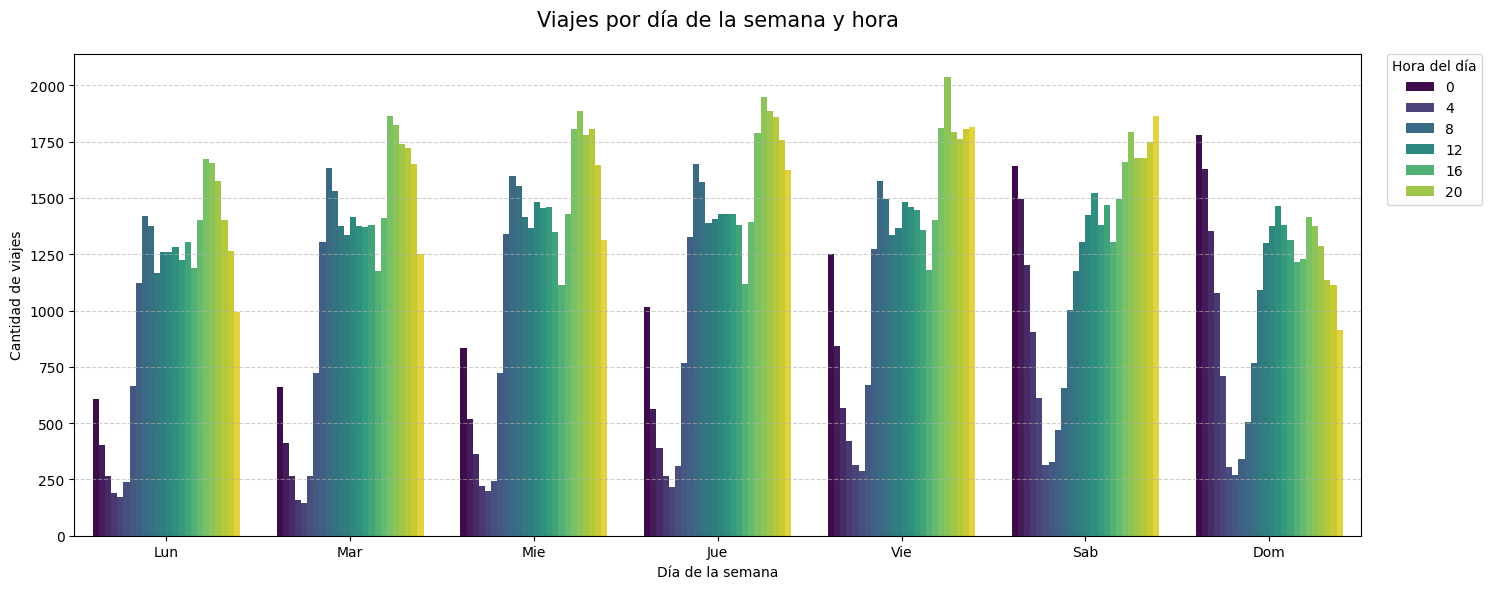

In [43]:
dias = ['Lun','Mar','Mie','Jue','Vie','Sab','Dom']

plt.figure(figsize=(15, 6))
ax = sns.countplot(x="day_of_week", hue="hour", data=df, palette="viridis")

plt.legend(title="Hora del día", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, ncol=1)

plt.xticks(ticks=range(7), labels=dias)

plt.title("Viajes por día de la semana y hora", fontsize=15, pad=20)
plt.xlabel("Día de la semana")
plt.ylabel("Cantidad de viajes")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
#0: Medianoche (12 AM)
#4: Madrugada (4 AM)
#8: Mañana (8 AM)
#12: Mediodia (12 PM)
#16: Tarde (4 PM)
#20: Noche (8 PM)

En el grafico de los **viajes por dia de la semana y hora** podemos observar que en cada día (de Lunes a Domingo), vemos una caída (Barras oscuras - Horas 0 a 5) que representa la madrugada. Los viajes bajan al mínimo entre las 3 AM y 5 AM. La subida (Barras azules/verdes - Horas 8 a 17) los viajes suben y se mantienen estables. Independientemente del día, el volumen más alto de viajes ocurre al final de la tarde y noche (de las 18:00 a las 21:00). De Lunes a Viernes los patrones son muy similares. Hay un pico matutino claro (alrededor de la hora 8), los Sábados y Domingos notamos que las barras oscuras (madrugada, hora 0 a 4) son mucho más altas que en los días de semana, esto refleja la actividad nocturna. La gente usa mucho más el transporte de madrugada los fines de semana por salidas recreativas. Domingo por la noche es el único momento donde las barras amarillas (noche) empiezan a bajar antes.

# Division del conjunto de datos

In [44]:
X = df.drop(columns=['fare_amount'])
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
n_train_inicial= len(X_train)

In [46]:
print("Total:", len(X))
print("Train:", len(X_train))
print("Test:", len(X_test))

Total: 199088
Train: 159270
Test: 39818


In [47]:
X_train.columns

Index(['key', 'date', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour',
       'day_of_week', 'day', 'month', 'year', 'is_weekend', 'is_holiday',
       'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos'],
      dtype='object')

# Imputacion de coordenadas fuera de NY

Se detectó la presencia de registros con coordenadas geográficas situadas fuera de los límites de la ciudad de Nueva York (posibles errores de GPS o valores en cero). En lugar de descartar estas filas y perder información valiosa, se decidió realizar una imputación mediante el algoritmo KNN. El objetivo fue 'traer' estas coordenadas erróneas al rango válido de NYC, asignándoles una ubicación lógica basada en la posición de sus 10 vecinos más cercanos, garantizando así la integridad y representatividad del dataset

In [48]:
subset = X_train[['pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude']].sample(5000, random_state=42).copy()

mask = np.random.rand(*subset.shape) < 0.1
subset_missing = subset.mask(mask)

for k in [3,5,7,10]:
    imputer = KNNImputer(n_neighbors=k, weights='distance')

    start = time.time()
    subset_imputed = imputer.fit_transform(subset_missing)
    end = time.time()

    mse = mean_squared_error(subset.values[mask], subset_imputed[mask])
    rmse = np.sqrt(mse)

    print(f"k={k}: RMSE={rmse:.4f}, Tiempo={end-start:.2f}s")

k=3: RMSE=2.9999, Tiempo=0.39s
k=5: RMSE=2.8741, Tiempo=0.38s
k=7: RMSE=2.5658, Tiempo=0.39s
k=10: RMSE=2.5246, Tiempo=0.38s


Se evaluaron distintos valores de k (3, 5, 7 y 10) simulando un 10% de valores faltantes sobre un subconjunto de 5000 registros de las coordenadas geográficas. El RMSE de imputación disminuyó consistentemente al aumentar k, estabilizándose a partir de k=10, donde la mejora marginal respecto a k=7 es la menor del rango evaluado, indicando el punto de convergencia. El tiempo de cómputo se mantuvo estable en todos los casos. Por estos motivos se eligió k=10 como valor óptimo, ya que minimiza el error de imputación sin costo computacional significativo.

In [49]:
#utilizamos knn para la imputacion de las coordenadas fuera de ny
#las coordenadas fuera de los límites de NYC las marcamos como NaN y las imputamos con KNN usando los vecinos mas cercanos
lat_min, lat_max = 40.49, 40.92
lon_min, lon_max = -74.27, -73.68

coord_cols = ['pickup_latitude', 'pickup_longitude','dropoff_latitude', 'dropoff_longitude']

#seleccionaomos todas las filas donde la latitud no este entre el minimo y el max y los asigna nulos
X_train.loc[~X_train['pickup_latitude'].between(lat_min, lat_max),   'pickup_latitude']  = np.nan
X_train.loc[~X_train['pickup_longitude'].between(lon_min, lon_max),  'pickup_longitude'] = np.nan
X_train.loc[~X_train['dropoff_latitude'].between(lat_min, lat_max),  'dropoff_latitude'] = np.nan
X_train.loc[~X_train['dropoff_longitude'].between(lon_min, lon_max), 'dropoff_longitude']= np.nan

print("coordenadas inválidas detectadas")
print(X_train[coord_cols].isna().sum())

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_train[coord_cols] = imputer.fit_transform(X_train[coord_cols])

X_test.loc[~X_test['pickup_latitude'].between(lat_min, lat_max),   'pickup_latitude']  = np.nan
X_test.loc[~X_test['pickup_longitude'].between(lon_min, lon_max),  'pickup_longitude'] = np.nan
X_test.loc[~X_test['dropoff_latitude'].between(lat_min, lat_max),  'dropoff_latitude'] = np.nan
X_test.loc[~X_test['dropoff_longitude'].between(lon_min, lon_max), 'dropoff_longitude']= np.nan

X_test[coord_cols] = imputer.transform(X_test[coord_cols])

print("\nNaN tras imputación en train:")
print(X_train[coord_cols].isna().sum())
print("\nNaN tras imputación en test:")
print(X_test[coord_cols].isna().sum())

coordenadas inválidas detectadas
pickup_latitude      3246
pickup_longitude     3267
dropoff_latitude     3251
dropoff_longitude    3261
dtype: int64

NaN tras imputación en train:
pickup_latitude      0
pickup_longitude     0
dropoff_latitude     0
dropoff_longitude    0
dtype: int64

NaN tras imputación en test:
pickup_latitude      0
pickup_longitude     0
dropoff_latitude     0
dropoff_longitude    0
dtype: int64


# Calculo de distancia

Agregamos la variable distancia_km, calculada a partir de las coordenadas geográficas de origen (pickup_latitude, pickup_longitude) y destino (dropoff_latitude, dropoff_longitude) mediante la fórmula de Haversine, la cual calcula la distancia entre el punto de origen y destino de cada viaje, considerando la curvatura de la Tierra. Esta fórmula es más adecuada que la distancia euclídea, ya que esta asume que la Tierra es un plano, pero en distancias reales debemos considerar la esfericidad terrestre.

In [50]:
def haversine(lat1, lon1, lat2, lon2): #fórmula utilizada para calcular la distancia entre dos puntos de una esfera dadas sus coordenadas de longitud y latitud
    #radio de la Tierra en km
    R = 6371

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2]) #convertimos grados a radianes

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

X_train['distance_km'] = haversine(
    X_train['pickup_latitude'],  X_train['pickup_longitude'],
    X_train['dropoff_latitude'], X_train['dropoff_longitude'])

X_test['distance_km'] = haversine(
    X_test['pickup_latitude'],  X_test['pickup_longitude'],
    X_test['dropoff_latitude'], X_test['dropoff_longitude'])


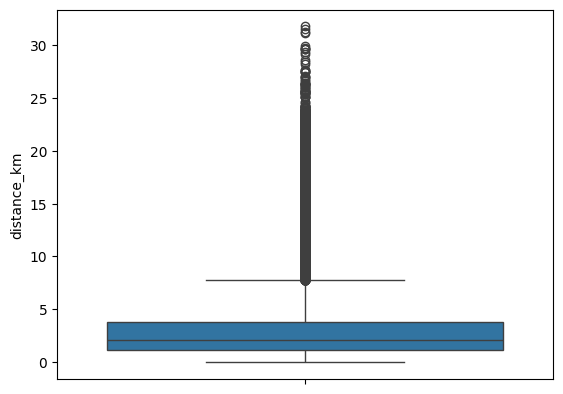

In [51]:
sns.boxplot(X_train["distance_km"])
plt.show()

El **boxplot de distancias** revela una fuerte concentración de viajes en trayectos cortos, con una mediana cercana a los 3 km. Sin embargo, se observa una gran dispersión de valores atípicos que alcanzan los 35 km.

In [52]:
X_train.loc[X_train['distance_km'] == X_train['distance_km'].max()]

,key,date,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week,...,year,is_weekend,is_holiday,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,distance_km
88587,5330361,2010-10-02,2010-10-02 02:27:33 UTC,-73.990375,40.573864,-73.93515,40.85623,1,2,5,...,2010,True,False,0.5,0.866025,-0.974928,-0.222521,-1.0,0.99653,31.740782


In [53]:
#vemos las filas del set de entrenamiento con distancia menos a 0
X_train[X_train['distance_km'] <= 0]

,key,date,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week,...,year,is_weekend,is_holiday,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,distance_km
4677,21807342,2009-10-25,2009-10-25 07:29:30 UTC,-73.946954,40.745115,-73.946954,40.745115,2,7,6,...,2009,True,False,0.965926,-0.258819,-0.781831,0.623490,-1.000000,0.99653,0.0
45041,46571149,2012-08-02,2012-08-02 07:45:43 UTC,-73.988855,40.753932,-73.988855,40.753932,5,7,3,...,2012,False,False,0.965926,-0.258819,0.433884,-0.900969,-0.500000,0.99653,0.0
4642,28188232,2010-04-14,2010-04-14 08:19:41 UTC,-73.955107,40.820113,-73.955107,40.820113,2,8,2,...,2010,False,False,0.866025,-0.500000,0.974928,-0.222521,1.000000,0.99653,0.0
55947,40182660,2012-12-12,2012-12-12 23:16:33 UTC,-73.974485,40.761327,-73.974485,40.761327,1,23,2,...,2012,False,False,-0.258819,0.965926,0.974928,-0.222521,-0.500000,0.99653,0.0
150239,42234928,2010-12-24,2010-12-24 05:40:32 UTC,-73.984598,40.742437,-73.984598,40.742437,1,5,4,...,2010,False,True,0.965926,0.258819,-0.433884,-0.900969,-0.500000,0.99653,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138591,38055362,2012-08-17,2012-08-17 01:19:39 UTC,-74.004033,40.742119,-74.004033,40.742119,1,1,4,...,2012,False,False,0.258819,0.965926,-0.433884,-0.900969,-0.500000,0.99653,0.0
107947,979569,2012-01-19,2012-01-19 08:58:33 UTC,-73.902053,40.763958,-73.902053,40.763958,1,8,3,...,2012,False,False,0.866025,-0.500000,0.433884,-0.900969,0.000000,0.99653,0.0
11156,29997685,2013-04-10,2013-04-10 13:46:08 UTC,-73.975687,40.798912,-73.975687,40.798912,1,13,2,...,2013,False,False,-0.258819,-0.965926,0.974928,-0.222521,1.000000,0.99653,0.0
110582,32740757,2013-05-03,2013-05-03 14:59:46 UTC,-74.002131,40.715036,-74.002131,40.715036,1,14,4,...,2013,False,False,-0.500000,-0.866025,-0.433884,-0.900969,0.866025,0.99653,0.0


In [54]:
X_train = X_train[X_train['distance_km'] > 0]
y_train = y_train.loc[X_train.index]

Luego de calcular la distance_km, se detectaron registros con distancias iguales a 0. Dado que un viaje por definición implica un desplazamiento, estas filas representaban errores de medición o cancelaciones que introducían ruido y distorsiones en el modelo. Por ello, se decidió eliminar estas observaciones.

# OHE

In [55]:
X_train.columns

Index(['key', 'date', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour',
       'day_of_week', 'day', 'month', 'year', 'is_weekend', 'is_holiday',
       'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
       'distance_km'],
      dtype='object')

In [56]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_train = encoder.fit_transform(X_train[['year']])

#transformar el set de test
ohe_test = encoder.transform(X_test[['year']])

In [57]:
cols_names = encoder.get_feature_names_out(['year'])

ohe_train_df = pd.DataFrame(ohe_train, columns=cols_names, index=X_train.index) #convertimos la matriz de números (ceros y unos) de nuevo a df
ohe_test_df = pd.DataFrame(ohe_test, columns=cols_names, index=X_test.index)

X_train = pd.concat([X_train.drop('year', axis=1), ohe_train_df], axis=1)
X_test = pd.concat([X_test.drop('year', axis=1), ohe_test_df], axis=1)

# Matriz de correlacion

In [58]:
X_train.columns

Index(['key', 'date', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour',
       'day_of_week', 'day', 'month', 'is_weekend', 'is_holiday', 'hour_sin',
       'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
       'distance_km', 'year_2009', 'year_2010', 'year_2011', 'year_2012',
       'year_2013', 'year_2014', 'year_2015'],
      dtype='object')

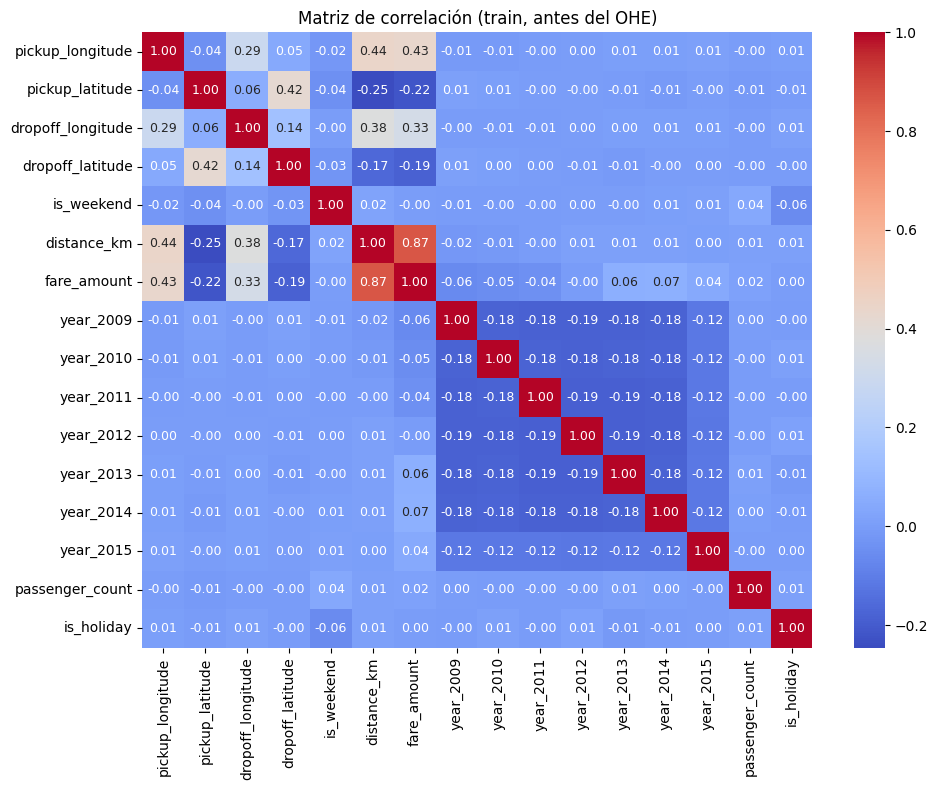

Correlación con fare_amount:
distance_km          0.867
pickup_longitude     0.433
dropoff_longitude    0.333
year_2014            0.070
year_2013            0.062
year_2015            0.044
passenger_count      0.016
is_holiday           0.002
is_weekend          -0.001
year_2012           -0.004
year_2011           -0.044
year_2010           -0.054
year_2009           -0.061
dropoff_latitude    -0.187
pickup_latitude     -0.219
Name: fare_amount, dtype: float64


In [59]:
df_corr = X_train.copy()
df_corr['fare_amount'] = y_train

columnas = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
            'dropoff_latitude', 'is_weekend', 'distance_km', 'fare_amount','year_2009',
       'year_2010', 'year_2011', 'year_2012', 'year_2013', 'year_2014',
       'year_2015', 'passenger_count','is_holiday']

corr = df_corr[columnas].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={'size': 9})
plt.title("Matriz de correlación (train, antes del OHE)")
plt.tight_layout()
plt.show()

print("Correlación con fare_amount:")
print(corr['fare_amount'].drop('fare_amount').sort_values(ascending=False).round(3))


# Eliminamos columnas que no aportan informacion

Se eliminarin variables que no aportaban al modelo, en primer lugar **key**, es un ID único; no hay un patrón en un número de serie que ayude a predecir el precio. Luego **pickup_datetime** el modelo no puede hacer cálculos matemáticos con una fecha escrita como "2026-04-15 10:30". Las variables **hour y day_of_week** las trasformamos en variables cíclicas (Seno y Coseno). Si dejaras las originales junto con las nuevas, tendríamos información repetida. La variable **day** fue eliminada ya que el número del día no influye en el precio, **date** tambien fue eliminada ya que el dia completo no nos aporta informacion y tenemos la nueva variable que nos dice si es dia laboral o no. La variable **passenger_count** en la matriz de correlación el número de pasajeros no afecta el precio (un viaje de 3 km sale lo mismo para uno que para cuatro personas). La variable **is_holiday** al igual que passenger_count podemos observar que en la matriz de correlacion no se relaciona con la variable fare_amount.

In [60]:
X_train = X_train.drop(columns=['key', 'date', 'pickup_datetime','hour', 'day_of_week', 'day', 'month', "passenger_count", "is_holiday"])
X_test  = X_test.drop(columns=['key', 'date', 'pickup_datetime','hour', 'day_of_week', 'day', 'month',"is_holiday", "passenger_count"])

print("Columnas finales:", X_train.columns.tolist())

Columnas finales: ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'distance_km', 'year_2009', 'year_2010', 'year_2011', 'year_2012', 'year_2013', 'year_2014', 'year_2015']


# Descartamos valores extremos

In [61]:
dist_limit = X_train['distance_km'].quantile(0.998)

#mascara para que el precio Y la distancia sean razonables sumamos que la distancia sea mayor a 0 para quitar los errores que vimos
mask_limpieza = (X_train['distance_km'] <= dist_limit) & \
                (X_train['distance_km'] > X_train['distance_km'].min())

X_train = X_train[mask_limpieza]
y_train = y_train.loc[X_train.index]

print(f"Filas finales en Train: {X_train.shape[0]}")
print(f"Máxima distancia: {X_train['distance_km'].max():.2f}")


Filas finales en Train: 157382
Máxima distancia: 22.09


# Escalado

In [62]:
X_train.columns

Index(['pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos', 'month_sin', 'month_cos', 'distance_km', 'year_2009',
       'year_2010', 'year_2011', 'year_2012', 'year_2013', 'year_2014',
       'year_2015'],
      dtype='object')

Aplicamos RobustScaler sobre las variables numéricas continuas (distancia y coordenadas). Decidimos no usar un escalado estándar para evitar que los valores atípicos de los viajes largos sesgaran la distribución.

In [63]:
#las codificadas cíclicamente ya están entre -1 y 1, no necesitan escalado
#is_workday ya es 0/1, no necesita
#year ya fue codificada

cols_a_escalar = ['distance_km','pickup_longitude', 'pickup_latitude', 'dropoff_longitude','dropoff_latitude']
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

scaler = RobustScaler()
X_train[cols_a_escalar] = scaler.fit_transform(X_train[cols_a_escalar])
X_test[cols_a_escalar]  = scaler.transform(X_test[cols_a_escalar])

print("Columnas finales:", X_train.columns.tolist())


Columnas finales: ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'distance_km', 'year_2009', 'year_2010', 'year_2011', 'year_2012', 'year_2013', 'year_2014', 'year_2015']


# Entrenamiento y predicciones

In [64]:
#alinear columnas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0) #aseguramos que Test tenga exactamente las mismas columnas que Train

X_train_final = X_train.select_dtypes(include=[np.number])
X_test_final  = X_test.select_dtypes(include=[np.number])

lr = LinearRegression()

#entrenamos
lr.fit(X_train_final, y_train)

#predecimos
y_pred_train = lr.predict(X_train_final)
y_pred_test  = lr.predict(X_test_final)

# Métodos de gradiente descendiente

In [65]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):
    """
    shapes:
        X_train = nxm
        y_train = nx1
        X_val = pxm
        y_test = px1
        W = mx1
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_val.shape[0]

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))


    # Inicializar pesos aleatorios
    W = np.random.randn(m+1).reshape(m+1, 1)

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        #print(error_train)
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum  # 1xm
        gradient = np.transpose(grad_mul).reshape(-1, 1)  # mx1

        W = W - (lr * gradient)

    # Graficar errores de entrenamiento y prueba
    # Definir una figura
    plt.figure(figsize=(12, 6))
    # Plotear errores de entrenamiento
    plt.plot(train_errors, label='Error de entrenamiento')
    # Plotear errores de prueba
    plt.plot(test_errors, label='Error de validación')
    # Poner labels en los ejes
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    # Activar la leyenda
    plt.legend()
    # Poner titulo
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    # Terminar y mostrar gráfico
    plt.show()

    return W

In [66]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    n, m = X_train.shape

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test  = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1, 1)

    train_errors = []
    test_errors  = []

    for i in range(epochs):
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            x_sample = X_train[j].reshape(-1, 1)   # (m+1, 1)
            y_sample = y_train[j]                   # escalar

            prediction = float(x_sample.T @ W)      # escalar limpio
            error      = y_sample - prediction

            gradient = -2 * error * x_sample        # (m+1, 1)
            W = W - lr * gradient

        # Errores calculados UNA vez por época
        train_pred = X_train @ W
        train_mse  = np.mean((y_train - train_pred) ** 2)
        train_errors.append(train_mse)

        test_pred = X_test @ W
        test_mse  = np.mean((y_test - test_pred) ** 2)
        test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors,  label='Error de prueba')
    plt.xlabel('Época')
    plt.ylabel('MSE')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs épocas (SGD)')
    plt.show()

    return W

In [67]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=15):
    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):

        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]


        for j in range(0, n, batch_size):
            # Obtener un lote (mini-batch) de datos
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size

            W = W - (lr * gradient)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (Mini-Batch GD)')
    plt.show()

    return W

In [68]:
#convertimos a np a una matriz de datos pura, np es mas rapido
X_train_np = X_train_final.values
y_train_np = y_train.values.reshape(-1, 1)
X_test_np = X_test_final.values
y_test_np = y_test.values.reshape(-1, 1)

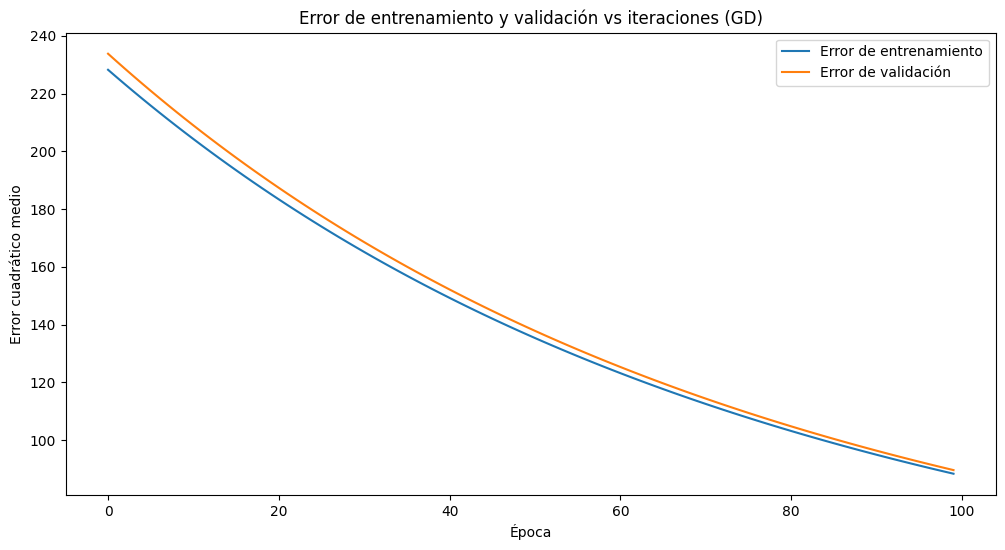

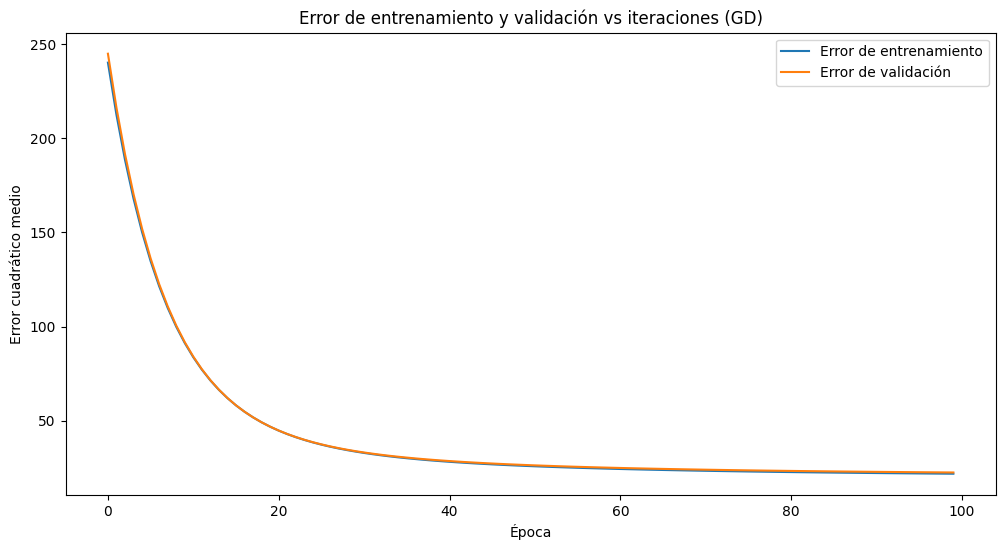

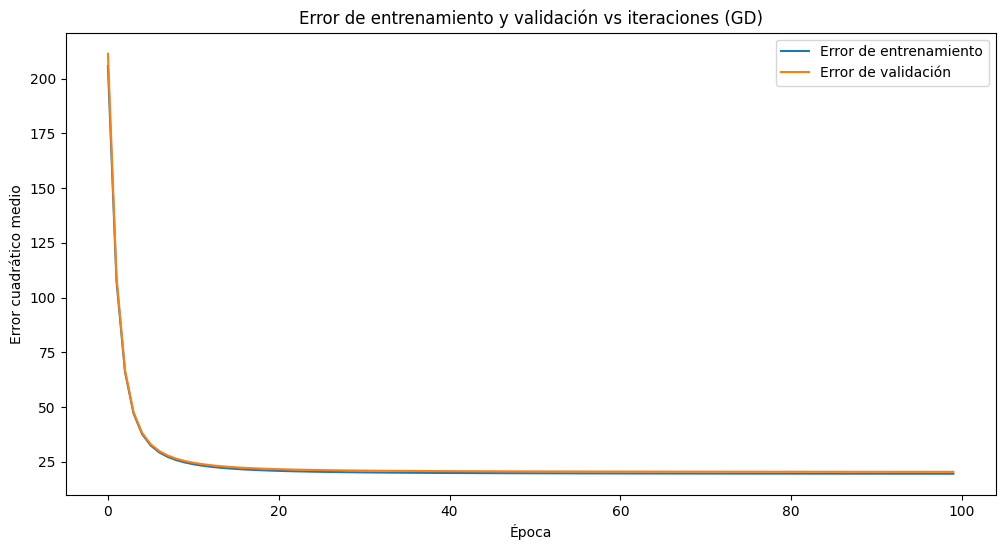

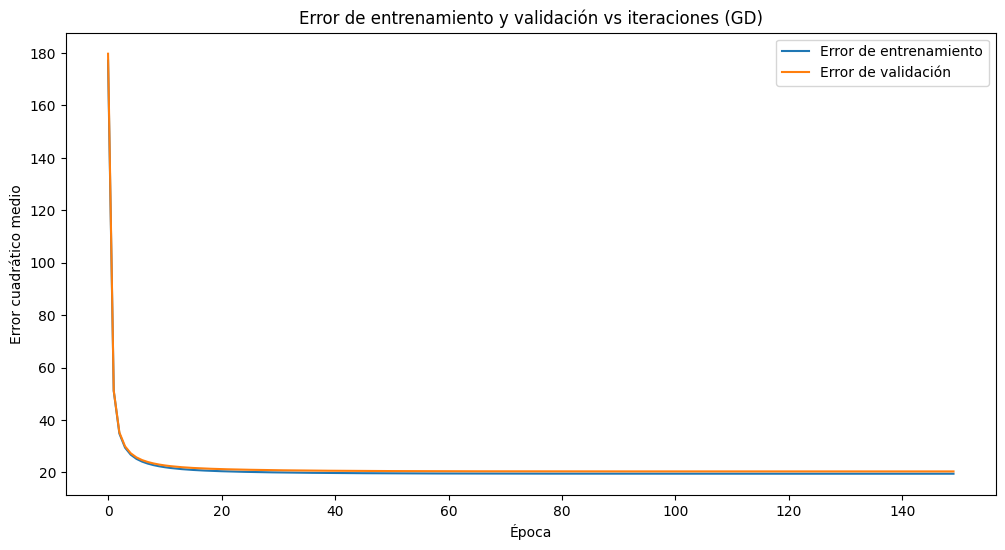

In [69]:
#probamos distintos learning rates, para analizar el comportamiento del algoritmo de gradiente descendente
W1 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.001, epochs=100)
W2 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.01, epochs=100)
W3 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.05, epochs=100)
W4 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.1, epochs=150)

En el Gradiente Descendente por Lote, observamos que al variar el Learning Rate, la curva de error cambia su trayectoria: con valores bajos el descenso es lento y lineal, mientras que con valores adecuados la caída es exponencial, logrando eficiencia. Por otro lado, la cantidad de Épocas define el punto de parada; observamos que en el primer grafico con lr=0.001 y epochs=100 a partir de la época 40 el error se estabiliza, indicando que el modelo ha convergido y que la estructura de los pesos ya es óptima para generalizar, en el segundo y tercer grafico con lr=0.01 y epochs=100/150 el algoritmo logra una caída exponencial mucho más agresiva, alcanzando la convergencia (el punto donde el error deja de bajar significativamente) en apenas 7 épocas. Esto demuestra que un lr adecuado optimiza drásticamente el tiempo de cómputo.

/tmp/ipykernel_6616/383535339.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prediction = float(x_sample.T @ W)      # escalar limpio


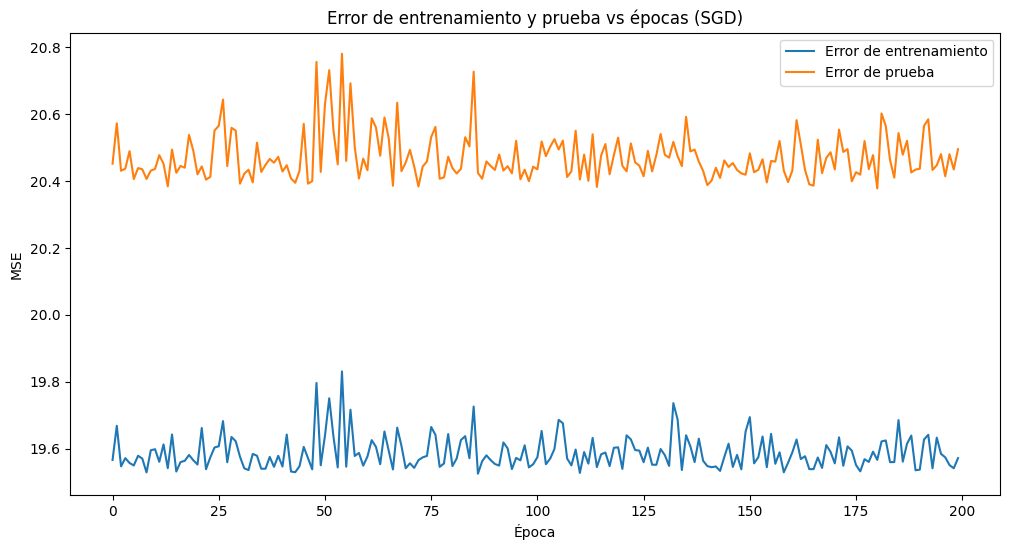

In [70]:
W_sgd = stochastic_gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.0001, epochs=200)

A diferencia de las curvas suaves del Gradiente por Lote, aquí observamos un comportamiento "serruchado". Esto es característico del SGD, ya que el modelo actualiza los pesos basándose en un solo registro a la vez. Esa variabilidad hace que el error no baje de forma lineal, sino que salte mientras busca el mínimo global. Aunque hay mucho ruido, se observa que a partir de la época 50, el error deja de tener una tendencia bajista. Esto indica que el modelo ha alcanzado una zona de estabilidad.

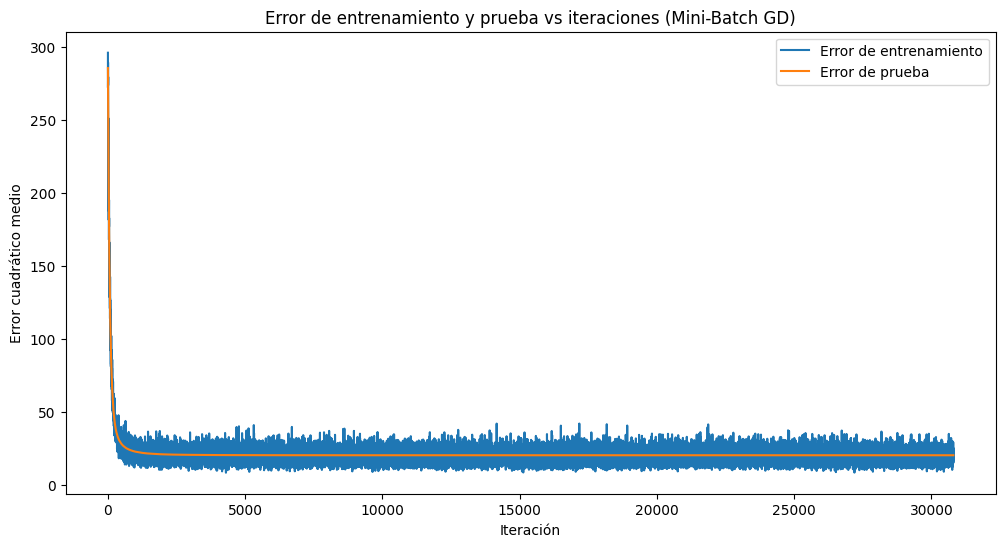

In [71]:
W_mini = mini_batch_gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.001, epochs=200, batch_size=1024)

Podemos observar que modelo cae en picada al principio y ya para la iteración ~1500 el error está planchado cerca de 25. El modelo Mini-Batch con un tamaño de lote de 1024 permitió alcanzar la convergencia de forma acelerada. A pesar del ruido inherente al procesamiento por lotes, la curva de prueba se mantuvo estable y alineada con la de entrenamiento.

Al comparar los tres métodos, observamos que el gradiente descediente por lote ofrece la mayor estabilidad y una convergencia suave, ideal para entender la relación global de los datos. El estocastico, aunque es ruidoso debido a la sensibilidad a datos individuales (outliers), demuestra ser eficiente para reducir el error rápidamente en términos generales. Por ultimo, el Mini-Batch logra estabilizar el ruido mediante el promedio de grupos de datos, permitiendo una convergencia rápida y computacionalmente eficiente. En los tres casos, la cercanía entre las curvas de entrenamiento y prueba indica una buena capacidad de generalización del modelo.

# Métodos de Regularización

Buscamos el mejor alpha para Lasso y Ridge por separado,
usando el mismo rango amplio de valores

In [72]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]

LASSO

In [73]:
resultados_lasso = []
for a in alphas:
    #usamos Lasso como referente por su sensibilidad para filtrar variables.
    #penaliza llevando coeficientes a exactamente 0, lo que permite identificar qué variables aportan al modelo
    modelo_prueba = Lasso(alpha=a, max_iter=10000).fit(X_train_final, y_train)
    #max_iter=10000 para garantizar convergencia
    y_pred = modelo_prueba.predict(X_test_final)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    resultados_lasso.append({'alpha': a, 'RMSE': rmse})

df_lasso = pd.DataFrame(resultados_lasso)
mejor_alpha_lasso = df_lasso.loc[df_lasso['RMSE'].idxmin(), 'alpha']
print(f"Mejor alpha Lasso: {mejor_alpha_lasso}")
display(df_lasso)

Mejor alpha Lasso: 0.01


,alpha,RMSE
0,0.0001,4.516353
1,0.0010,4.516285
2,0.0100,4.516266
3,0.1000,4.574682
4,1.0000,4.736112
5,10.0000,9.141801
6,100.0000,9.267808


RIDGE

In [74]:
resultados_ridge = []
for a in alphas:
    modelo_ridge = Ridge(alpha=a).fit(X_train_final, y_train)
    y_pred = modelo_ridge.predict(X_test_final)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    resultados_ridge.append({'alpha': a, 'RMSE': rmse})

df_ridge = pd.DataFrame(resultados_ridge)
mejor_alpha_ridge = df_ridge.loc[df_ridge['RMSE'].idxmin(), 'alpha']
print(f"Mejor alpha Ridge: {mejor_alpha_ridge}")
display(df_ridge)

Mejor alpha Ridge: 100.0


,alpha,RMSE
0,0.0001,4.516362
1,0.0010,4.516362
2,0.0100,4.516362
3,0.1000,4.516362
4,1.0000,4.516360
5,10.0000,4.516346
6,100.0000,4.516209


Al variar los hiperparámetros, observamos que Ridge muestra una gran robustez, logrando su mejor desempeño con una penalización alta (alpha=100), lo que sugiere que el modelo se beneficia de reducir la magnitud de todos los coeficientes de forma equitativa. Por el contrario, Lasso presenta un comportamiento más sensible: existe un rango óptimo de penalización (alpha=0) que permite simplificar el modelo sin perder precisión. Sin embargo, al incrementar el alpha por encima de este valor, el error se duplica rápidamente, lo que evidencia que Lasso está eliminando variables críticas para la predicción, cayendo en un claro escenario de subajuste (underfitting)

# Metricas para ambos conjuntos

In [75]:
modelos_finales = {
    'Regresión Lineal': LinearRegression(),
    'Ridge': Ridge(alpha=mejor_alpha_ridge),
    'Lasso': Lasso(alpha=mejor_alpha_lasso, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=mejor_alpha_lasso, l1_ratio=0.5, max_iter=10000)}

In [76]:
res_list = []

for nombre, mod in modelos_finales.items():
    mod.fit(X_train_final, y_train)
    p_train = mod.predict(X_train_final)
    p_test = mod.predict(X_test_final)

    res_list.append({
        'Modelo': nombre,
        'RMSE Train': np.sqrt(mean_squared_error(y_train, p_train)),
        'RMSE Test': np.sqrt(mean_squared_error(y_test, p_test)),
        'R2 Train': r2_score(y_train, p_train),
        'R2 Test': r2_score(y_test, p_test),
        'MAPE Test': mean_absolute_percentage_error(y_test, p_test)})

X_train_bias = np.c_[np.ones(X_train_np.shape[0]), X_train_np]
X_test_bias = np.c_[np.ones(X_test_np.shape[0]), X_test_np]

gradientes = {
    'GD por Lote': W4,
    'GD Mini-Batch': W_mini,
    'GD Estocástico': W_sgd}

for nombre, W in gradientes.items():
    p_train_manual = X_train_bias @ W
    p_test_manual = X_test_bias @ W

    res_list.append({
        'Modelo': nombre,
        'RMSE Train': np.sqrt(mean_squared_error(y_train_np, p_train_manual)),
        'RMSE Test': np.sqrt(mean_squared_error(y_test_np, p_test_manual)),
        'R2 Train': r2_score(y_train_np, p_train_manual),
        'R2 Test': r2_score(y_test_np, p_test_manual),
        'MAPE Test': mean_absolute_percentage_error(y_test_np, p_test_manual)})

df_comparativa = pd.DataFrame(res_list)
df_comparativa = df_comparativa.sort_values(by="Modelo", key=lambda col: col.map(lambda x: 0 if "Regresión Lineal" in x else (1 if "GD" in x else 2))).reset_index(drop=True)
print("Comparación final")
display(df_comparativa)

Comparación final


,Modelo,RMSE Train,RMSE Test,R2 Train,R2 Test,MAPE Test
0,Regresión Lineal,4.418013,4.516362,0.763707,0.762517,0.245058
1,GD Estocástico,4.424026,4.527145,0.763063,0.761382,0.252632
2,GD Mini-Batch,4.418020,4.516523,0.763706,0.762500,0.245189
3,GD por Lote,4.418199,4.516400,0.763687,0.762513,0.244711
4,ElasticNet,4.418829,4.515530,0.763619,0.762605,0.244660
5,Lasso,4.418774,4.516266,0.763625,0.762527,0.244121
6,Ridge,4.418017,4.516209,0.763706,0.762533,0.245052


Calculamos las métricas para ambos conjuntos porque la comparación entre ellos es lo que nos permite evaluar la capacidad de generalización del modelo. Por un lado las métricas en entrenamiento nos dicen qué tan bien el modelo es capaz de ajustar la curva a los datos conocidos. Por otro lado, las métricas en prueba nos dicen qué tan bien el modelo generaliza ante situaciones nuevas. Si solo miráramos el entrenamiento, podríamos tener un modelo perfecto (con error nulo) que en la realidad no sirva para nada. Si el error de Test es mucho más grande que el de Train, el modelo estudia de memoria. Si son parecidos, el modelo es aprende y entiende los datos.

Al analizar la tabla comparativa, se observa una paridad casi absoluta entre todas las implementaciones. El hecho de que los métodos de Gradiente Descendente (Lote, Mini-Batch y Estocástico) alcancen métricas de $R^2$ (~ 0.762) y RMSE (~ 4.51 USD) prácticamente idénticas a la Regresión Lineal, valida la correcta convergencia de los algoritmos. En cuanto al comportamiento de los modelos, destacamos que en todos los casos, la diferencia entre el RMSE Train y el RMSE Test es mínima (menor al 3%). Esto confirma que el modelo posee una excelente capacidad de generalización y no ha memorizado los datos de entrenamiento. Respecto al impacto de la regularizacion, los modelos Ridge, Lasso y ElasticNet no presentan mejoras significativas sobre el modelo base. Esto es técnicamente coherente con los hiperparámetros $\alpha$ óptimos encontrados, los cuales fueron extremadamente bajos. A la hora de seleccionar un modelo final, se optó por la Regresión Lineal o Ridge. Ambos destacan por su estabilidad matemática y simplicidad computacional, ofreciendo un desempeño sólido sin necesidad de configuraciones complejas.

# Graficos de residuos

Los gráficos de residuos muestran que los errores están centrados
en 0, sin sesgo sistemático. Sin embargo, se observa heterocedasticidad:
la dispersión de los residuos es mayor para predicciones bajas y
disminuye para predicciones altas. Esto sugiere que el modelo lineal no captura completamente la variabilidad en viajes cortos.
Los cuatro modelos presentan el mismo patrón, consistente con sus
métricas similares.

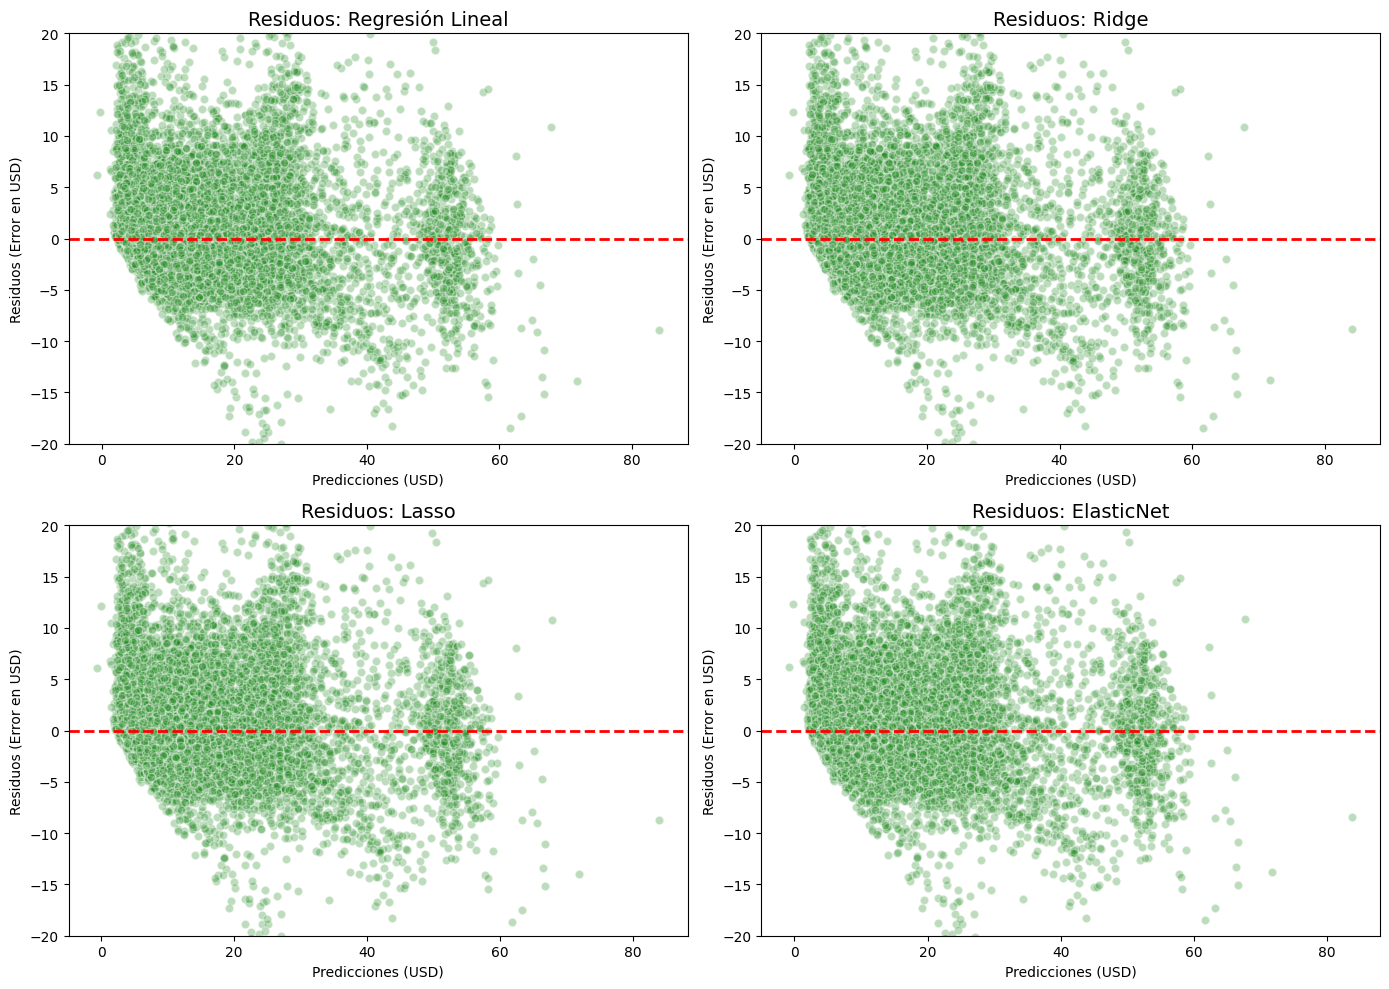

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (nombre, modelo) in enumerate(modelos_finales.items()):
    y_pred = modelo.predict(X_test_final)
    residuos = y_test - y_pred

    axes[i].scatter(y_pred, residuos, alpha=0.3, color='forestgreen', edgecolors='white')
    axes[i].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[i].set_title(f"Residuos: {nombre}", fontsize=14)
    axes[i].set_xlabel("Predicciones (USD)")
    axes[i].set_ylabel("Residuos (Error en USD)")
    axes[i].set_ylim(-20, 20) #ajustar según escala de error

plt.tight_layout()
plt.show()

# Conclusiones finales

A lo largo de este trabajo se desarrolló un modelo predictivo
para estimar las tarifas de viajes de Uber en Nueva York,
utilizando técnicas de regresión lineal múltiple.

Durante el preprocesamiento se realizó una limpieza exhaustiva
del dataset: se eliminaron registros con coordenadas inválidas,
pasajeros fuera de rango (0 o más de 6) y tarifas atípicas.
Las coordenadas fuera del área de Nueva York fueron imputadas
mediante KNN. Se crearon variables temporales (hora, día, mes)
con codificación cíclica para preservar su naturaleza periódica,
y se calculó la distancia de cada viaje mediante la fórmula de
Haversine, que resultó ser la variable más correlacionada con
la tarifa.

En cuanto a los modelos, la Regresión Lineal  obtuvo
un RMSE de 4.418 USD en train y	4.517 USD en test, con un R2
de 0.76. La diferencia pequeña entre ambos conjuntos confirma
que no hay overfitting significativo y el modelo generaliza bien.

Respecto a la regularización, los cuatro modelos (Regresión
Lineal, Ridge, Lasso y ElasticNet) obtuvieron métricas
prácticamente idénticas. El mejor alpha encontrado fue 0.0001,
lo que indica que la penalización no aporta mejora en este
dataset. Se concluye que no existe overfitting relevante y
que la regularización no es necesaria en este caso.

En cuanto al gradiente descendiente, el Batch GD mostró
convergencia suave y estable. SGD presentó mayor ruido por
actualizar con una muestra a la vez, y Mini-Batch fue el
punto intermedio. La tasa de aprendizaje resultó el
hiperparámetro más crítico: valores muy bajos convergen
lento y valores muy altos pueden divergir.

El mejor modelo seleccionado es la Regresión Lineal múltiple,
por ser el más simple con igual rendimiento que los modelos
regularizados. Un RMSE de ~4.418 USD sobre una tarifa promedio
de ~11 USD representa un error razonable, aunque los gráficos
de residuos muestran heterocedasticidad, lo que sugiere que
la relación entre las variables no es completamente lineal
y podría mejorarse con modelos más complejos.